# Recipe 03 — Crafting reference signals

**Goal.** Build the `reference_signal` array in every shape you'll need — steps, ramps, doublets, sinusoids, and composite schedules — and see how they look.

**Related.** [Recipe 02](02_env_anatomy.md) for how `reference_signal` is consumed by the env, [Recipe 09](09_fault_tolerance.md) for signals designed to trigger faults.

## Shape contract

The env expects `reference_signal.shape == (len(tracking_states), number_time_steps)`. For a single tracked channel you still need a 2-D reshape — `np.reshape(sig, (1, -1))`.

The library ships with primitive builders in `tensoraerospace.signals.standart`. They all take the time vector `tp = generate_time_period(tn=T, dt=dt)` as their first argument.

## 1. The primitives

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np

from tensoraerospace.signals.standart import (
    unit_step, ramp, pulse, sinusoid, sinusoid_vertical_shift,
    square_wave, constant_line,
)
from tensoraerospace.utils import generate_time_period

dt = 0.01
tp = generate_time_period(tn=10, dt=dt)       # 10 s, 1001 ticks

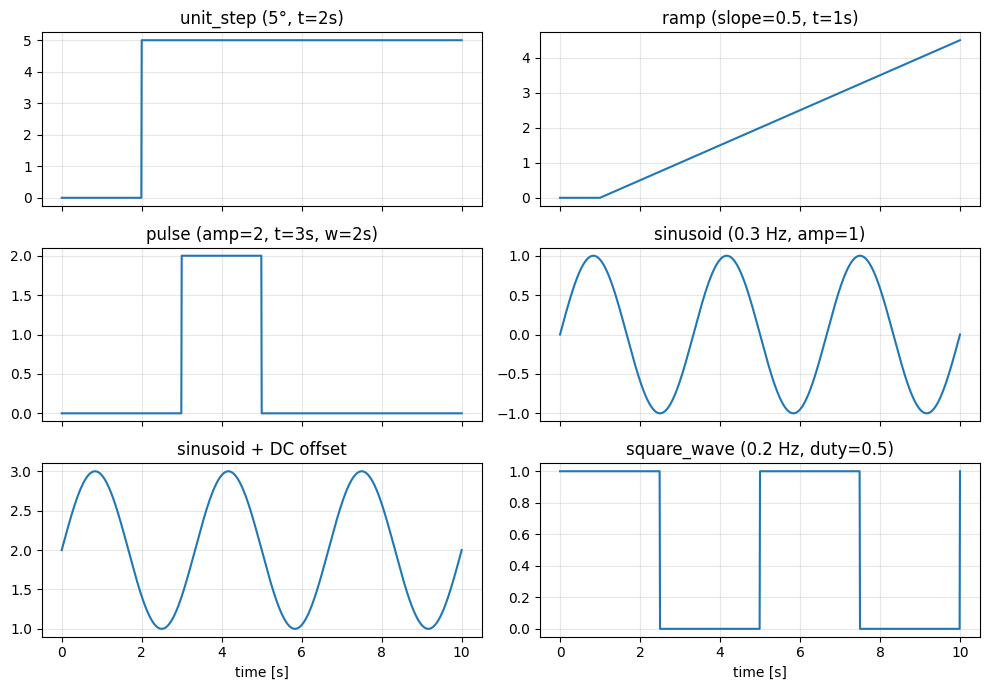

In [2]:
fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True)

axes[0, 0].plot(tp, unit_step(tp=tp, degree=5, time_step=2.0))
axes[0, 0].set_title('unit_step (5°, t=2s)')

axes[0, 1].plot(tp, ramp(tp=tp, slope=0.5, time_start=1.0))
axes[0, 1].set_title('ramp (slope=0.5, t=1s)')

axes[1, 0].plot(tp, pulse(tp=tp, amplitude=2.0, time_start=3.0, width=2.0))
axes[1, 0].set_title('pulse (amp=2, t=3s, w=2s)')

axes[1, 1].plot(tp, sinusoid(tp=tp, frequency=0.3, amplitude=1.0))
axes[1, 1].set_title('sinusoid (0.3 Hz, amp=1)')

axes[2, 0].plot(tp, sinusoid_vertical_shift(tp=tp, frequency=0.3, amplitude=1.0, vertical_shift=2.0))
axes[2, 0].set_title('sinusoid + DC offset')
axes[2, 0].set_xlabel('time [s]')

axes[2, 1].plot(tp, square_wave(tp=tp, frequency=0.2, amplitude=1.0))
axes[2, 1].set_title('square_wave (0.2 Hz, duty=0.5)')
axes[2, 1].set_xlabel('time [s]')

for ax in axes.flat:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Composite schedules — doublets and hold-and-release

Real flight tests rarely use a clean sinusoid. A **doublet** (positive pulse followed by a negative pulse, returning to zero) is the standard excitation for frequency-response identification. A **hold-and-release** schedule ramps up to several distinct levels, holds each, then returns to zero — perfect for batch LS-based policy evaluators like iADP.

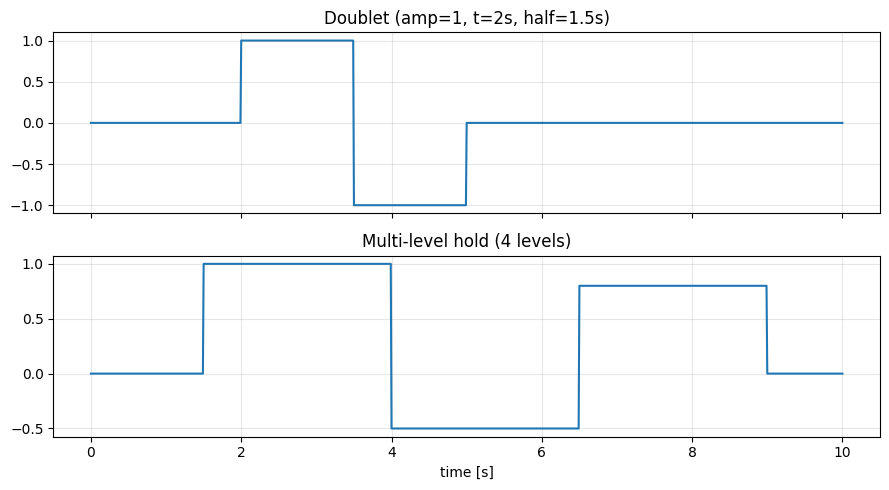

In [3]:
def doublet(tp, amplitude, t_start, half_width):
    '''Symmetric doublet: +amp for half_width, then -amp for half_width.'''
    return (pulse(tp=tp, amplitude=amplitude, time_start=t_start, width=half_width)
            + pulse(tp=tp, amplitude=-amplitude, time_start=t_start + half_width, width=half_width))

def multi_step(tp, schedule):
    '''Piecewise-constant schedule. schedule is [(t_start, level), ...].'''
    sig = np.zeros_like(tp)
    for t_start, level in schedule:
        sig += unit_step(tp=tp, degree=level, time_step=t_start)              - unit_step(tp=tp, degree=level, time_step=tp[-1] + 1.0)   # never fires again
    # Better: stacked piecewise
    sig = np.zeros_like(tp)
    for i, (t_start, level) in enumerate(schedule):
        next_t = schedule[i+1][0] if i+1 < len(schedule) else tp[-1] + 1.0
        mask = (tp >= t_start) & (tp < next_t)
        sig[mask] = level
    return sig

doublet_sig = doublet(tp, amplitude=1.0, t_start=2.0, half_width=1.5)
multi = multi_step(tp, [(0.0, 0.0), (1.5, 1.0), (4.0, -0.5), (6.5, 0.8), (9.0, 0.0)])

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(tp, doublet_sig); axes[0].set_title('Doublet (amp=1, t=2s, half=1.5s)')
axes[0].grid(alpha=0.3)
axes[1].plot(tp, multi); axes[1].set_title('Multi-level hold (4 levels)')
axes[1].grid(alpha=0.3); axes[1].set_xlabel('time [s]')
plt.tight_layout(); plt.show()

## 3. Smoothed transitions

Discontinuous steps excite all frequencies at once — including the actuator-bandwidth band where the plant saturates. In practice you want **smoothed** edges. The simplest way is a `tanh` transition between levels.

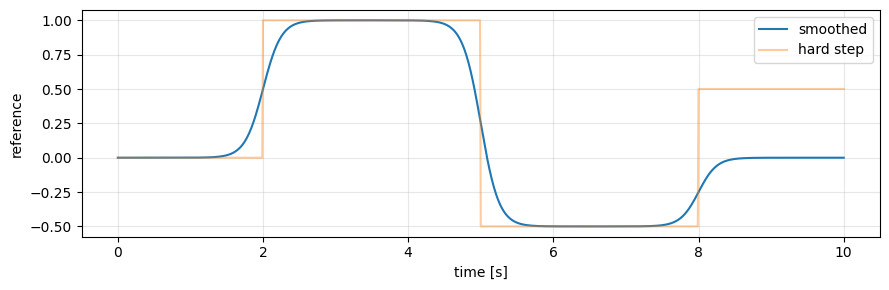

In [4]:
def smooth_step(tp, from_level, to_level, t_mid, transition_time):
    '''Tanh transition from from_level to to_level centred at t_mid.'''
    k = 4.0 / max(transition_time, 1e-6)   # 4/τ ⇒ ~98 % settling within τ
    return from_level + 0.5 * (to_level - from_level) * (1.0 + np.tanh(k * (tp - t_mid)))

smooth = (smooth_step(tp, 0.0, 1.0, t_mid=2.0, transition_time=1.0)
          + smooth_step(tp, 0.0, -1.5, t_mid=5.0, transition_time=1.0)
          + smooth_step(tp, 0.0, 0.5, t_mid=8.0, transition_time=1.0))

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(tp, smooth, label='smoothed')
ax.plot(tp, multi_step(tp, [(0.0, 0.0), (2.0, 1.0), (5.0, -0.5), (8.0, 0.5)]),
        alpha=0.4, label='hard step')
ax.set_xlabel('time [s]'); ax.set_ylabel('reference')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Feeding into an env

Whatever you build, always reshape to `(n_tracking_states, T)` before passing to `gym.make()`:

```python
reference_signal = np.reshape(smooth, (1, -1))
env = gym.make('LinearLongitudinalF16-v0',
    number_time_steps=len(tp),
    reference_signal=reference_signal,
    tracking_states=['alpha'],
    ...)
```

For multi-channel tracking (e.g. 6-DoF roll/pitch/yaw), stack separately:

```python
ref_p = doublet(tp, 0.3, 2.0, 1.0)
ref_q = smooth_step(tp, 0.0, 0.5, 4.0, 0.5)
ref_r = np.zeros_like(tp)
reference_signal = np.stack([ref_p, ref_q, ref_r], axis=0)
# tracking_states=['p', 'q', 'r']
```

## Rules of thumb

- **For PID / MPC benchmarking** — pulses and doublets. Classical control papers report settling time, overshoot, and static error from these.
- **For adaptive-critic agents (IHDP / IM-GDHP / iADP)** — multi-level hold. Different levels excite cross-terms of the value function so policy-eval LS stays well-conditioned.
- **For RL training** — randomised schedules. Draw each episode's signal from a distribution (random step times, levels, transition widths) to avoid overfit.
- **For frequency-response ID** — chirp or multi-sine. The iADP notebook uses a two-tone multi-sine `2*sin(2π·0.7t) + 1*sin(2π·1.5t)` to seed the RLS.

## Where to go next

- **[Recipe 04 — Choosing an agent](04_choosing_agent.md)** — matches reference shape to agent capability.
- **[Recipe 09 — Fault-tolerance](09_fault_tolerance.md)** — combines command signals with actuator faults.